# Day 01：瓶颈的觉醒 —— Seq2Seq 的信息瓶颈与注意力的萌芽> 🚀 第十一周 · 注意力时代 · 第 1 天上周我们看到了 Seq2Seq 的致命瓶颈：**整个源句子被压缩成一个固定长度的向量**。句子一长，信息就丢失了。今天，我们要认识一个改变深度学习历史的思想：**注意力机制（Attention）**。**今天的任务**：1. 深入理解 Seq2Seq 的信息瓶颈2. 认识注意力的核心直觉：翻译时"回头看"3. 用代码验证：固定向量 vs 动态关注---

## 1. 历史剧场：2014 年的"瓶颈之痛"2014 年 Seq2Seq 模型发表后，人们很快发现了一个问题：> **句子超过 20 个词，翻译质量就急剧下降。**原因很简单：不管源句子多长，Encoder 都要把它压缩成一个固定大小的向量。就像把一整本书的内容塞进一张便利贴——信息必然丢失。2015 年，Bahdanau 等人提出了一个天才的想法：> **为什么非要把整个句子压缩成一个向量？翻译每个词的时候，能不能"回头看"源句子的不同部分？**这就是**注意力机制**的诞生。---

## 2. 生活隐喻：翻译官的"回头看"- **没有注意力**：翻译官听完一整句话，然后凭记忆翻译。句子一长，就忘了前面的内容- **有注意力**：翻译官在翻译每个词时，都可以回头看原文，找到与当前翻译最相关的部分具体例子：

<p align="center">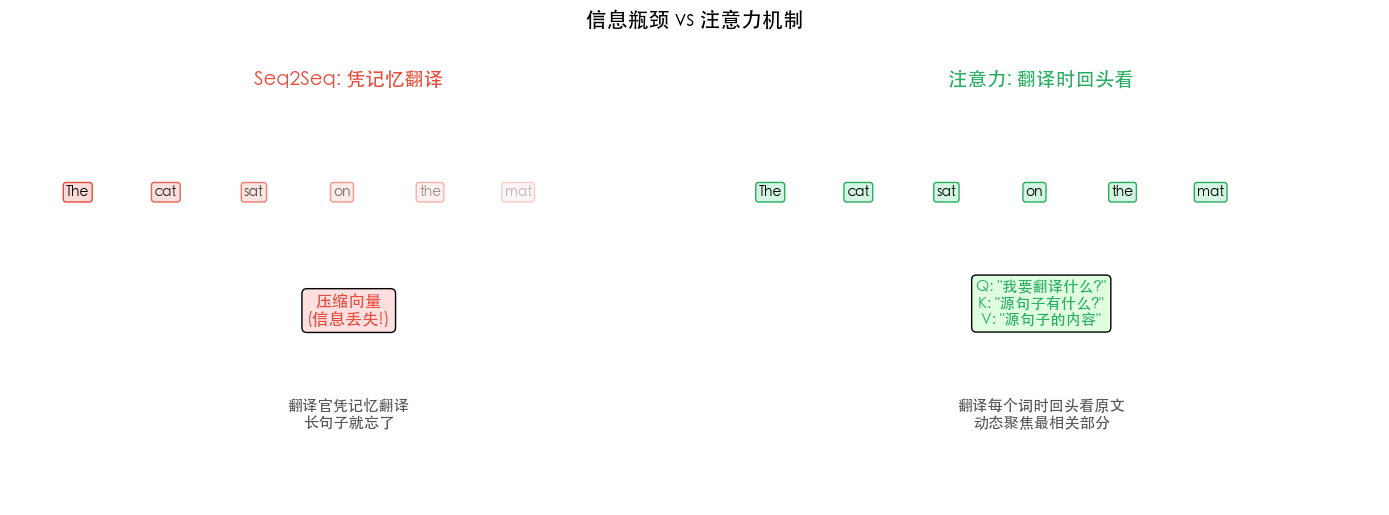</p>*Seq2Seq瓶颈 vs 注意力机制对比图*

源: "The cat sat on the mat"翻译 "猫" 时 → 回看 "cat" → 高度关注翻译 "坐" 时 → 回看 "sat" → 高度关注翻译 "在" 时 → 回看 "on" → 高度关注翻译 "垫子" 时 → 回看 "mat" → 高度关注

**关键洞察**：注意力让模型在翻译每个词时，都能动态地"聚焦"到源句子中最相关的部分，而不是依赖一个固定的压缩向量。---

## 3. 数学直觉：注意力 = 查询 × 键注意力的核心是三个向量：| 符号 | 含义 | 直觉 ||---|---|---|| **Q** (Query) | 查询 | "我现在要翻译什么？" || **K** (Key) | 键 | "源句子每个词的'标签'" || **V** (Value) | 值 | "源句子每个词的'内容'" |计算过程：1. **打分**：用 Q 和每个 K 计算相似度 → $score_i = Q \cdot K_i$2. **归一化**：用 softmax 把分数变成概率 → $\alpha_i = \text{softmax}(score_i)$3. **加权求和**：用概率对 V 加权求和 → $context = \sum \alpha_i V_i$直觉：Q 是"我要找什么"，K 是"每个位置有什么"，V 是"每个位置的内容"。Q 和 K 越相似，注意力权重越高，该位置的 V 贡献越大。---

## 4. 代码实验室：从信息瓶颈到动态关注

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 模拟信息瓶颈

In [ ]:
np.random.seed(42)seq_len = 20hidden_dim = 8source_info = np.random.randn(seq_len, hidden_dim)bottleneck = source_info.mean(axis=0)reconstruction_error = []for i in range(seq_len):    error = np.linalg.norm(source_info[i] - bottleneck)    reconstruction_error.append(error)print("信息瓶颈：用均值向量重建每个位置的信息")print(f"平均重建误差: {np.mean(reconstruction_error):.4f}")print(f"最大重建误差: {np.max(reconstruction_error):.4f}")

### 4.2 手写注意力机制

In [ ]:
def simple_attention(query, keys, values):    scores = query @ keys.T    weights = F.softmax(torch.tensor(scores, dtype=torch.float32), dim=-1).numpy()    context = weights @ values    return context, weightscontexts = []all_weights = []for i in range(seq_len):    query = source_info[i]    context, weights = simple_attention(query, source_info, source_info)    contexts.append(context)    all_weights.append(weights)contexts = np.array(contexts)attn_errors = [np.linalg.norm(source_info[i] - contexts[i]) for i in range(seq_len)]print(f"\n注意力机制：用动态关注重建每个位置的信息")print(f"平均重建误差: {np.mean(attn_errors):.4f}")print(f"最大重建误差: {np.max(attn_errors):.4f}")print(f"\n注意力比瓶颈的误差降低了: {(1 - np.mean(attn_errors)/np.mean(reconstruction_error))*100:.1f}%")

### 4.3 可视化注意力权重

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].bar(range(seq_len), reconstruction_error, color='#e74c3c', alpha=0.7, label='瓶颈重建误差')axes[0].bar(range(seq_len), attn_errors, color='#27ae60', alpha=0.7, label='注意力重建误差')axes[0].set_xlabel('序列位置', fontsize=12)axes[0].set_ylabel('重建误差', fontsize=12)axes[0].set_title('信息瓶颈 vs 注意力：重建误差对比', fontsize=14)axes[0].legend(fontsize=11)axes[0].grid(True, alpha=0.3)attn_matrix = np.array(all_weights)im = axes[1].imshow(attn_matrix, aspect='auto', cmap='YlOrRd')axes[1].set_xlabel('源位置 (Key)', fontsize=12)axes[1].set_ylabel('查询位置 (Query)', fontsize=12)axes[1].set_title('注意力权重热力图', fontsize=14)plt.colorbar(im, ax=axes[1], label='注意力权重')plt.tight_layout()plt.show()

### 解读- **重建误差**：注意力的重建误差远低于瓶颈——动态关注比固定压缩好得多- **注意力热力图**：对角线附近权重最高——每个位置最关注自己附近的源位置---

## 今日结语今天我们认识了 Seq2Seq 的信息瓶颈，以及注意力的核心直觉：**翻译时"回头看"**。注意力的本质是：用查询（Q）去匹配键（K），从而提取值（V）。这让模型不再依赖一个固定的压缩向量，而是动态地关注最相关的信息。明天，我们将深入注意力的数学细节，手写一个完整的注意力层。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 翻译时回头看原文 | 注意力机制——动态关注源序列 || 一张便利贴装不下一本书 | 信息瓶颈——固定向量无法表示长序列 || "我要找什么" | Query (Q)——查询向量 || "每个位置有什么" | Key (K)——键向量 || "每个位置的内容" | Value (V)——值向量 || 相似度越高越关注 | Q·K 点积 → softmax → 注意力权重 |